# Cell 1 — 安装 Sionna
# 首次运行后 Runtime 会自动重启，重启后从 Cell 2 开始。

In [ ]:
import sys, os

try:
    import sionna.rt
    import sionna
    print(f"Sionna 已就绪，版本: {sionna.__version__}")
except ImportError:
    if 'google.colab' in sys.modules:
        print("首次安装 Sionna，Runtime 将自动重启，请重启后从 Cell 2 开始运行。")
        os.system("pip install -q sionna")
        os.kill(os.getpid(), 5)
    else:
        raise

Sionna 已就绪，版本: 2.0.1


# Cell 2 — 环境初始化
# 职责：挂载 Drive、解压 zip、修复 models/ 目录、定义路径变量。
# 输出变量：DRIVE_DIR, WORK_DIR, WEIGHTS_PATH（供后续 Cell 使用）

In [ ]:
import os, sys, zipfile, glob
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = "/content/drive/MyDrive/jscc_project"
ZIP_PATH  = f"{DRIVE_DIR}/colab_rt.zip"
WORK_DIR  = "/content/jscc"

if not os.path.exists(WORK_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(WORK_DIR)
    print(f"解压完成 → {WORK_DIR}")
else:
    print("目录已存在，跳过解压")

os.chdir(WORK_DIR)
sys.path.insert(0, WORK_DIR)

# models/__init__.py 里的 import 会触发 BART 模型的加载链，必须清空。
# models/channels.py 依赖 Sionna 0.x 的废弃路径，用 stub 版替换。
with open("models/__init__.py", "w") as f:
    f.write("")

with open("models/channels.py", "w") as f:
    f.write("""\
import tensorflow as tf

class ChannelAWGN(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, x, ebno_db=10.0, training=False, ebno_db_override=None):
        if ebno_db_override is not None:
            ebno_db = ebno_db_override
        ebno_linear = tf.cast(10.0 ** (float(ebno_db) / 10.0), tf.float32)
        noise_std = tf.sqrt(tf.reduce_mean(tf.square(x)) / (2.0 * ebno_linear) + 1e-10)
        return x + tf.random.normal(tf.shape(x), stddev=noise_std)


class ChannelCDL(tf.keras.layers.Layer):
    \"\"\"接口存根，RT 实验中不实际调用，仅供 import。\"\"\"
    def __init__(self, cdl_model="A", fec_type="LDPC5G", fec_num_iter=6,
                 channel_num_tx_ant=2, channel_num_rx_ant=2,
                 num_bits_per_symbol=4, ebno_db_min=5, ebno_db_max=15, **kwargs):
        super().__init__(**kwargs)
        self.ebno_db_min = ebno_db_min
        self.ebno_db_max = ebno_db_max

    def call(self, x, ebno_db=None, training=False, ebno_db_override=None):
        if ebno_db_override is not None:
            ebno_db = ebno_db_override
        if ebno_db is None:
            ebno_db = tf.random.uniform([], self.ebno_db_min, self.ebno_db_max)
        noise_std = tf.sqrt(tf.reduce_mean(tf.square(x)) /
                            (2.0 * 10.0 ** (float(ebno_db) / 10.0)) + 1e-10)
        return x + tf.random.normal(tf.shape(x), stddev=noise_std)
""")

weight_files = glob.glob("checkpoints/image-jscc/recon_ld512_*/best_psnr*.weights.h5")
if not weight_files:
    raise FileNotFoundError("找不到 ld=512 权重文件，请确认 zip 包含对应的 checkpoints 目录")
WEIGHTS_PATH = sorted(weight_files)[-1]

print(f"DRIVE_DIR:    {DRIVE_DIR}")
print(f"WORK_DIR:     {WORK_DIR}")
print(f"WEIGHTS_PATH: {WEIGHTS_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
目录已存在，跳过解压
DRIVE_DIR:    /content/drive/MyDrive/jscc_project
WORK_DIR:     /content/jscc
WEIGHTS_PATH: checkpoints/image-jscc/recon_ld512_2026-03-25_03-50-35/best_psnr23.92.weights.h5


# Cell 3 — 全局配置（单一事实来源）
#   所有后续 Cell 依赖的参数都在这里集中定义，不会散落在各个 Cell 里。
#   切换场景：修改 ACTIVE_SCENE 然后从 Cell 5 重新运行。
#   调整实验参数：修改对应变量然后从相关 Cell 重新运行。

In [ ]:
# ── 场景选择（改这一行切换城市）────────────────────────────────────────────
ACTIVE_SCENE = "sydney"     # 可选："munich" | "etoile" | "sydney"

# ── 语义模型参数 ─────────────────────────────────────────────────────────────
LATENT_DIM = 512

# ── 5G NR 系统参数（与官方 PUSCH Notebook 保持一致）────────────────────────
subcarrier_spacing = 30e3   # Hz，5G NR μ=1（30 kHz 子载波间隔）
num_time_steps     = 14     # 每个 slot 的 OFDM 符号数
num_tx_ant         = 4      # 每个 UE 的天线数
num_rx_ant         = 16     # 基站天线数
batch_size_cir     = 100    # 每批 RT 计算的用户数

# ── 链路预算参数 ─────────────────────────────────────────────────────────────
# 调低发射功率使 SNR 动态范围覆盖 -10~25 dB，充分展示空间差异性
TX_POWER_DBM    = -10.0     # UE 上行发射功率（dBm）
NOISE_POWER_DBM = -95.0     # 热噪声底噪，BW=20MHz，噪声系数 7dB（dBm）

# ── CIR 缓存路径（Drive 持久存储）───────────────────────────────────────────
# 缓存文件名包含场景名，切换场景后自动使用不同缓存，互不干扰。
# 若要强制重新计算（比如修改了采样参数），手动删除 Drive 里对应的 .npy 文件。
CIR_CACHE = {
    "a":                  f"{DRIVE_DIR}/cache_{ACTIVE_SCENE}_a.npy",
    "tau":                f"{DRIVE_DIR}/cache_{ACTIVE_SCENE}_tau.npy",
    "ue_positions_valid": f"{DRIVE_DIR}/cache_{ACTIVE_SCENE}_ue_pos.npy",
}

print(f"ACTIVE_SCENE:   {ACTIVE_SCENE}")
print(f"LATENT_DIM:     {LATENT_DIM}")
print(f"num_rx_ant:     {num_rx_ant}  |  num_tx_ant: {num_tx_ant}")
print(f"TX_POWER_DBM:   {TX_POWER_DBM} dBm")
print(f"CIR 缓存前缀:   {DRIVE_DIR}/cache_{ACTIVE_SCENE}_*.npy")


ACTIVE_SCENE:   sydney
LATENT_DIM:     512
num_rx_ant:     16  |  num_tx_ant: 4
TX_POWER_DBM:   -10.0 dBm
CIR 缓存前缀:   /content/drive/MyDrive/jscc_project/cache_sydney_*.npy


# Cell 4 — 导入库 + 加载语义模型 + 预计算 PSNR-SNR 查找表 + 预计算 PSNR-SNR 查找表
# 依赖：Cell 2 的 WEIGHTS_PATH，Cell 3 的 LATENT_DIM
# 输出：sem_model, x_test, LOOKUP_SNRS, LOOKUP_PSNRS, snr_to_psnr()

In [ ]:
import numpy as np
import json, re, os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import h5py

# 只导入 sionna.rt，不导入 sionna.phy（后者基于 PyTorch，与 TF 共存会冲突）
import sionna
import sionna.rt as srt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver,
                       Camera, PathSolver, RadioMapSolver)

import tensorflow as tf
for g in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)

from train_reconstruction import ReconstructionModel, psnr as semantic_psnr
print(f"Sionna {sionna.__version__} | TF {tf.__version__} | 导入完成")


def load_weights_correct(model, weights_path):
    """
    Keras 2 → Keras 3 跨版本权重加载。

    h5 文件按字母顺序存储层名（conv2d_10 排在 conv2d_2 之前），
    Keras 3 按构建顺序遍历变量（conv2d_2 在 conv2d_10 之前）。
    解决方案：两边都按（层类型, 层编号数字, weight 类型）排序后位置对应赋值。
    """
    def sort_key(path):
        parts = path.split('/')
        layer = parts[0]
        wtype = parts[-1].replace(':0', '')
        m     = re.search(r'_(\d+)$', layer)
        idx   = int(m.group(1)) if m else 0
        ltype = re.sub(r'_\d+$', '', layer)
        return (ltype, idx, wtype)

    h5_sorted = {}
    with h5py.File(weights_path, 'r') as f:
        for group in ['encoder', 'decoder']:
            if group not in f:
                continue
            entries = []
            def collect(name, obj, e=entries):
                if isinstance(obj, h5py.Dataset):
                    e.append((sort_key(name), np.array(obj)))
            f[group].visititems(collect)
            entries.sort(key=lambda x: x[0])
            h5_sorted[group] = [arr for _, arr in entries]

    total_loaded = 0
    for group in ['encoder', 'decoder']:
        submodel = getattr(model, group, None)
        if submodel is None or group not in h5_sorted:
            continue
        keras_vars = sorted(
            [(sort_key(v.path), v) for v in submodel.weights],
            key=lambda x: x[0]
        )
        for (_, var), arr in zip(keras_vars, h5_sorted[group]):
            if var.shape == arr.shape:
                var.assign(arr)
                total_loaded += 1

    print(f"权重加载：{total_loaded} / "
          f"{sum(len(v) for v in h5_sorted.values())} 个变量")
    return total_loaded


dummy     = tf.zeros((2, 32, 32, 3))
sem_model = ReconstructionModel(
    latent_dim=LATENT_DIM, bypass=False, channel_type='analog')
sem_model(dummy, training=False)
load_weights_correct(sem_model, WEIGHTS_PATH)

(_, _), (x_test_raw, _) = tf.keras.datasets.cifar10.load_data()
x_test = x_test_raw[:200].astype('float32') / 255.0

def evaluate_psnr_at_snr(snr_db: float) -> float:
    m = tf.keras.metrics.Mean()
    for batch in tf.data.Dataset.from_tensor_slices(x_test).batch(32):
        x_hat = tf.clip_by_value(
            sem_model(batch, ebno_db=float(snr_db), training=False), 0, 1)
        m.update_state(semantic_psnr(batch, x_hat))
    return float(m.result())

print("预计算 PSNR-SNR 查找表（约 1-2 分钟）...")
LOOKUP_SNRS  = list(range(-10, 31, 2))
LOOKUP_PSNRS = [evaluate_psnr_at_snr(s) for s in LOOKUP_SNRS]

def snr_to_psnr(snr_db: float) -> float:
    """RT 计算的接收 SNR → 语义模型对应的 PSNR（线性插值）。"""
    return float(np.interp(snr_db, LOOKUP_SNRS, LOOKUP_PSNRS))

for s, p in zip(LOOKUP_SNRS, LOOKUP_PSNRS):
    print(f"  SNR={s:4d}dB → PSNR={p:.2f}dB")

Sionna 2.0.1 | TF 2.19.0 | 导入完成
权重加载：96 / 96 个变量
预计算 PSNR-SNR 查找表（约 1-2 分钟）...
  SNR= -10dB → PSNR=10.82dB
  SNR=  -8dB → PSNR=12.09dB
  SNR=  -6dB → PSNR=13.49dB
  SNR=  -4dB → PSNR=15.42dB
  SNR=  -2dB → PSNR=16.94dB
  SNR=   0dB → PSNR=18.44dB
  SNR=   2dB → PSNR=19.96dB
  SNR=   4dB → PSNR=21.00dB
  SNR=   6dB → PSNR=21.98dB
  SNR=   8dB → PSNR=22.57dB
  SNR=  10dB → PSNR=23.07dB
  SNR=  12dB → PSNR=23.33dB
  SNR=  14dB → PSNR=23.54dB
  SNR=  16dB → PSNR=23.65dB
  SNR=  18dB → PSNR=23.72dB
  SNR=  20dB → PSNR=23.78dB
  SNR=  22dB → PSNR=23.80dB
  SNR=  24dB → PSNR=23.83dB
  SNR=  26dB → PSNR=23.84dB
  SNR=  28dB → PSNR=23.84dB
  SNR=  30dB → PSNR=23.86dB


# Cell 5 — 场景设置
# 依赖：Cell 2 的 DRIVE_DIR，Cell 3 的所有系统参数和 ACTIVE_SCENE，
# Cell 4 的 srt（用于引用内置场景）
# 输出：scene, bird_cam, cfg, SAMPLE_MIN_DIST, SAMPLE_MAX_DIST, SCENE_DESCRIPTION
# 切换场景只需修改 Cell 3 里的 ACTIVE_SCENE，此 Cell 无需任何改动。

In [ ]:
import os, zipfile
import numpy as np

SCENE_CONFIGS = {

    "munich": {
        "source":       "builtin",
        "scene_ref":    srt.scene.munich,
        "bs_position":  [8.5, 21.0, 27.0],
        "bs_look_at":   [45., 90., 1.5],
        "cam_position": [0, 80, 500],
        "cam_orient":   np.array([0., np.pi/2., -np.pi/2.]),
        "min_dist":     10,
        "max_dist":     400,
        "description":  "Munich, Germany (Sionna built-in)",
    },

    "etoile": {
        "source":       "builtin",
        "scene_ref":    srt.scene.etoile,
        "bs_position":  [0.0, 0.0, 30.0],
        "bs_look_at":   [100., 0., 1.5],
        "cam_position": [0, 0, 500],
        "cam_orient":   np.array([0., np.pi/2., 0.]),
        "min_dist":     10,
        "max_dist":     300,
        "description":  "Paris, France — Place de l'Etoile (Sionna built-in)",
    },

    "sydney": {
        "source":       "custom",
        "scene_ref":    "/content/sydney_scene/sydney_cbd.xml",
        "zip_path":     f"{DRIVE_DIR}/sydney_scene.zip",
        "extract_dir":  "/content/sydney_scene",
        # 基站坐标来自 convert_to_mitsuba.py 运行时打印的推荐值
        # 场景范围 X(-284~282m) Y(-281~253m) Z(0~283m)
        "bs_position":  [-1.0, 15.7, 84.8],
        "bs_look_at":   [-1.0, 15.7, 1.5],
        "cam_position": [0, 0, 800],
        "cam_orient":   np.array([0., np.pi/2., 0.]),
        "min_dist":     10,
        "max_dist":     350,
        "description":  "Sydney CBD, Australia (QVB area, custom OSM scene)",
    },

    # 新增场景模板（复制此段，填入对应参数）：
    # "your_city": {
    #     "source":       "custom",
    #     "scene_ref":    "/content/your_city/your_city.xml",
    #     "zip_path":     f"{DRIVE_DIR}/your_city.zip",
    #     "extract_dir":  "/content/your_city",
    #     "bs_position":  [x, y, z],
    #     "bs_look_at":   [x, y, 1.5],
    #     "cam_position": [0, 0, altitude],
    #     "cam_orient":   np.array([0., np.pi/2., 0.]),
    #     "min_dist":     10,
    #     "max_dist":     400,
    #     "description":  "City, Country (custom OSM scene)",
    # },
}

cfg = SCENE_CONFIGS[ACTIVE_SCENE]

if cfg["source"] == "builtin":
    scene = load_scene(cfg["scene_ref"])
elif cfg["source"] == "custom":
    if not os.path.exists(cfg["extract_dir"]):
        print(f"解压自定义场景：{cfg['zip_path']} ...")
        with zipfile.ZipFile(cfg["zip_path"], 'r') as z:
            z.extractall("/content/")
        print("解压完成")
    scene = load_scene(cfg["scene_ref"])

scene.frequency = 3.5e9

scene.tx_array = PlanarArray(
    num_rows=1, num_cols=num_rx_ant // 2,
    vertical_spacing=0.5, horizontal_spacing=0.5,
    pattern="tr38901", polarization="cross"
)
tx = Transmitter(
    name="tx",
    position=cfg["bs_position"],
    look_at=cfg["bs_look_at"],
    display_radius=3.
)
scene.add(tx)
bird_cam = Camera(position=cfg["cam_position"], orientation=cfg["cam_orient"])

SAMPLE_MIN_DIST   = cfg["min_dist"]
SAMPLE_MAX_DIST   = cfg["max_dist"]
SCENE_DESCRIPTION = cfg["description"]

print(f"场景：{SCENE_DESCRIPTION}")
print(f"BS 位置：{tx.position}")
print(f"UE 采样距离：{SAMPLE_MIN_DIST} ~ {SAMPLE_MAX_DIST} m")

场景：Sydney CBD, Australia (QVB area, custom OSM scene)
BS 位置：[[-1, 15.7, 84.8]]
UE 采样距离：10 ~ 350 m


# Cell 6 — 计算 Radio Map
# 依赖：Cell 5 的 scene, bird_cam
# 输出：rm
# Radio Map 对象（Dr.Jit 类型）无法序列化保存，每次重连需重算，约 1-3 分钟。

In [ ]:
print("计算 Radio Map（约 1-3 分钟）...")
rm_solver = RadioMapSolver()
rm = rm_solver(scene, max_depth=5, cell_size=(5., 5.), samples_per_tx=int(5e6))
print("Radio Map 完成")

计算 Radio Map（约 1-3 分钟）...
Radio Map 完成


# Cell 7 — 批量 CIR 计算
# 依赖：Cell 3 的系统参数和 CIR_CACHE，
# Cell 5 的 scene/rm/SAMPLE_MIN_DIST/SAMPLE_MAX_DIST/bird_cam
# 输出：a, tau, ue_positions_valid
# Drive 缓存策略：
#   首次运行约 30 分钟，之后重连直接加载约 30 秒。
#   缓存文件名含场景名，切换场景后自动使用不同缓存。
#   强制重算：手动删除 Drive 里对应的 cache_{scene}_*.npy 文件。

批量 CIR 生成（5 批 × 100 个位置）...

CIR 已缓存到 Drive，共 495 个有效位置
a 形状: (495, 1, 16, 4, 46, 14)


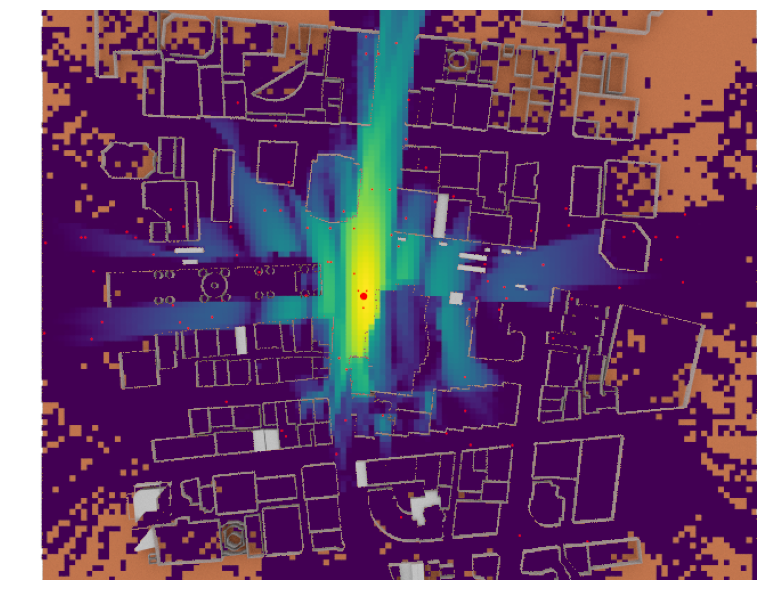

In [ ]:
import numpy as np, os

if os.path.exists(CIR_CACHE["a"]):
    a                  = np.load(CIR_CACHE["a"])
    tau                = np.load(CIR_CACHE["tau"])
    ue_positions_valid = np.load(CIR_CACHE["ue_positions_valid"])
    print(f"从 Drive 加载 CIR 缓存（{ACTIVE_SCENE} 场景）")
    print(f"  a: {a.shape}，有效 UE: {ue_positions_valid.shape[0]}")

else:
    scene.rx_array = PlanarArray(
        num_rows=1, num_cols=num_tx_ant // 2,
        vertical_spacing=0.5, horizontal_spacing=0.5,
        pattern="iso", polarization="cross"
    )

    first_pos, _ = rm.sample_positions(
        num_pos=batch_size_cir, metric="path_gain",
        min_val_db=-130, max_val_db=0,
        min_dist=SAMPLE_MIN_DIST, max_dist=SAMPLE_MAX_DIST, seed=0
    )
    for i in range(batch_size_cir):
        scene.remove(f"rx-{i}") if scene.get(f"rx-{i}") else None
        scene.add(Receiver(name=f"rx-{i}",
                           position=first_pos[0][i].numpy(),
                           display_radius=1., color=(1, 0, 0)))

    scene.render(camera=bird_cam, radio_map=rm, rm_vmin=-110, clip_at=12.)

    target_num_cirs = 500
    num_runs        = int(np.ceil(target_num_cirs / batch_size_cir))
    a_list, tau_list, ue_pos_list = [], [], []
    max_num_paths = 0
    p_solver = PathSolver()

    print(f"批量 CIR 生成（{num_runs} 批 × {batch_size_cir} 个位置）...")
    for run_idx in range(num_runs):
        print(f"  进度: {run_idx+1}/{num_runs}", end="\r")
        ue_pos, _ = rm.sample_positions(
            num_pos=batch_size_cir, metric="path_gain",
            min_val_db=-130, max_val_db=0,
            min_dist=SAMPLE_MIN_DIST, max_dist=SAMPLE_MAX_DIST,
            seed=run_idx
        )
        for i in range(batch_size_cir):
            scene.receivers[f"rx-{i}"].position = ue_pos[0][i].numpy()

        paths      = p_solver(scene, max_depth=5, max_num_paths_per_src=10**6)
        a_b, tau_b = paths.cir(
            sampling_frequency=subcarrier_spacing,
            num_time_steps=num_time_steps, out_type='numpy'
        )
        a_list.append(a_b)
        tau_list.append(tau_b)
        ue_pos_list.append(ue_pos[0].numpy())
        max_num_paths = max(max_num_paths, a_b.shape[-2])

    # Pad + 拼接（动态适配维度，兼容 Sionna 1.x 的 6 维输出）
    a_padded, tau_padded = [], []
    for a_, tau_ in zip(a_list, tau_list):
        pad_a   = [[0,0]] * (a_.ndim - 2) + \
                  [[0, max_num_paths - a_.shape[-2]]] + [[0,0]]
        pad_tau = [[0,0]] * (tau_.ndim - 1) + \
                  [[0, max_num_paths - tau_.shape[-1]]]
        a_padded.append(np.pad(a_, pad_a))
        tau_padded.append(np.pad(tau_, pad_tau))

    a   = np.concatenate(a_padded,   axis=0)
    tau = np.concatenate(tau_padded, axis=0)
    ue_positions_all = np.concatenate(ue_pos_list, axis=0)

    # 上行方向转置（利用信道互易性，Sionna 1.x 的 6 维格式）
    a   = np.transpose(a,   (0, 2, 3, 1, 4, 5))
    tau = np.transpose(tau, (0, 2, 1))

    # 过滤全零 CIR
    valid = np.sum(np.abs(a)**2, axis=tuple(range(1, a.ndim))) > 0.
    a, tau = a[valid], tau[valid]
    ue_positions_valid = ue_positions_all[valid]

    # 保存到 Drive
    np.save(CIR_CACHE["a"],                  a)
    np.save(CIR_CACHE["tau"],                tau)
    np.save(CIR_CACHE["ue_positions_valid"], ue_positions_valid)
    print(f"\nCIR 已缓存到 Drive，共 {a.shape[0]} 个有效位置")

print(f"a 形状: {a.shape}")

# Cell 8 — 从 CIR 提取接收 SNR，映射到语义 PSNR
# 依赖：Cell 3 的链路预算参数和 NORM_FACTOR，
#       Cell 4 的 snr_to_psnr()，Cell 5 的 cfg，Cell 7 的 a/ue_positions_valid
# 输出：snr_arr, distance_arr, psnr_arr, xs, ys

In [ ]:
BS_POS      = np.array(cfg["bs_position"])
NORM_FACTOR = num_rx_ant * num_tx_ant

snr_list, distance_list, psnr_list = [], [], []

for idx in range(len(a)):
    path_gain = np.sum(np.abs(a[idx])**2) / NORM_FACTOR
    snr_db    = float(np.clip(
        TX_POWER_DBM + 10.0 * np.log10(max(path_gain, 1e-30)) - NOISE_POWER_DBM,
        -10.0, 30.0))
    dist = float(np.linalg.norm(ue_positions_valid[idx] - BS_POS))
    snr_list.append(snr_db)
    distance_list.append(dist)
    psnr_list.append(snr_to_psnr(snr_db))

snr_arr      = np.array(snr_list)
distance_arr = np.array(distance_list)
psnr_arr     = np.array(psnr_list)
xs, ys       = ue_positions_valid[:, 0], ue_positions_valid[:, 1]

print(f"有效位置: {len(snr_arr)}  |  "
      f"SNR: {snr_arr.min():.1f}~{snr_arr.max():.1f} dB  |  "
      f"PSNR: {psnr_arr.min():.2f}~{psnr_arr.max():.2f} dB")

with open("site_specific_results.json", "w") as f:
    json.dump([{"idx": i,
                "position": ue_positions_valid[i].tolist(),
                "distance_m": round(float(distance_arr[i]), 1),
                "snr_db":    round(float(snr_arr[i]),    2),
                "psnr_db":   round(float(psnr_arr[i]),   2)}
               for i in range(len(snr_arr))], f, indent=2)


有效位置: 495  |  SNR: -10.0~20.8 dB  |  PSNR: 10.82~23.79 dB


# Cell 9 — 绘图
# 依赖：Cell 3 的 LATENT_DIM，Cell 5 的 SCENE_DESCRIPTION 和 cfg，
#       Cell 8 的所有数组
# 输出：site_specific_results.png + site_specific_heatmap.png

/tmp/ipykernel_4690/1378972398.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp   = ax.boxplot(


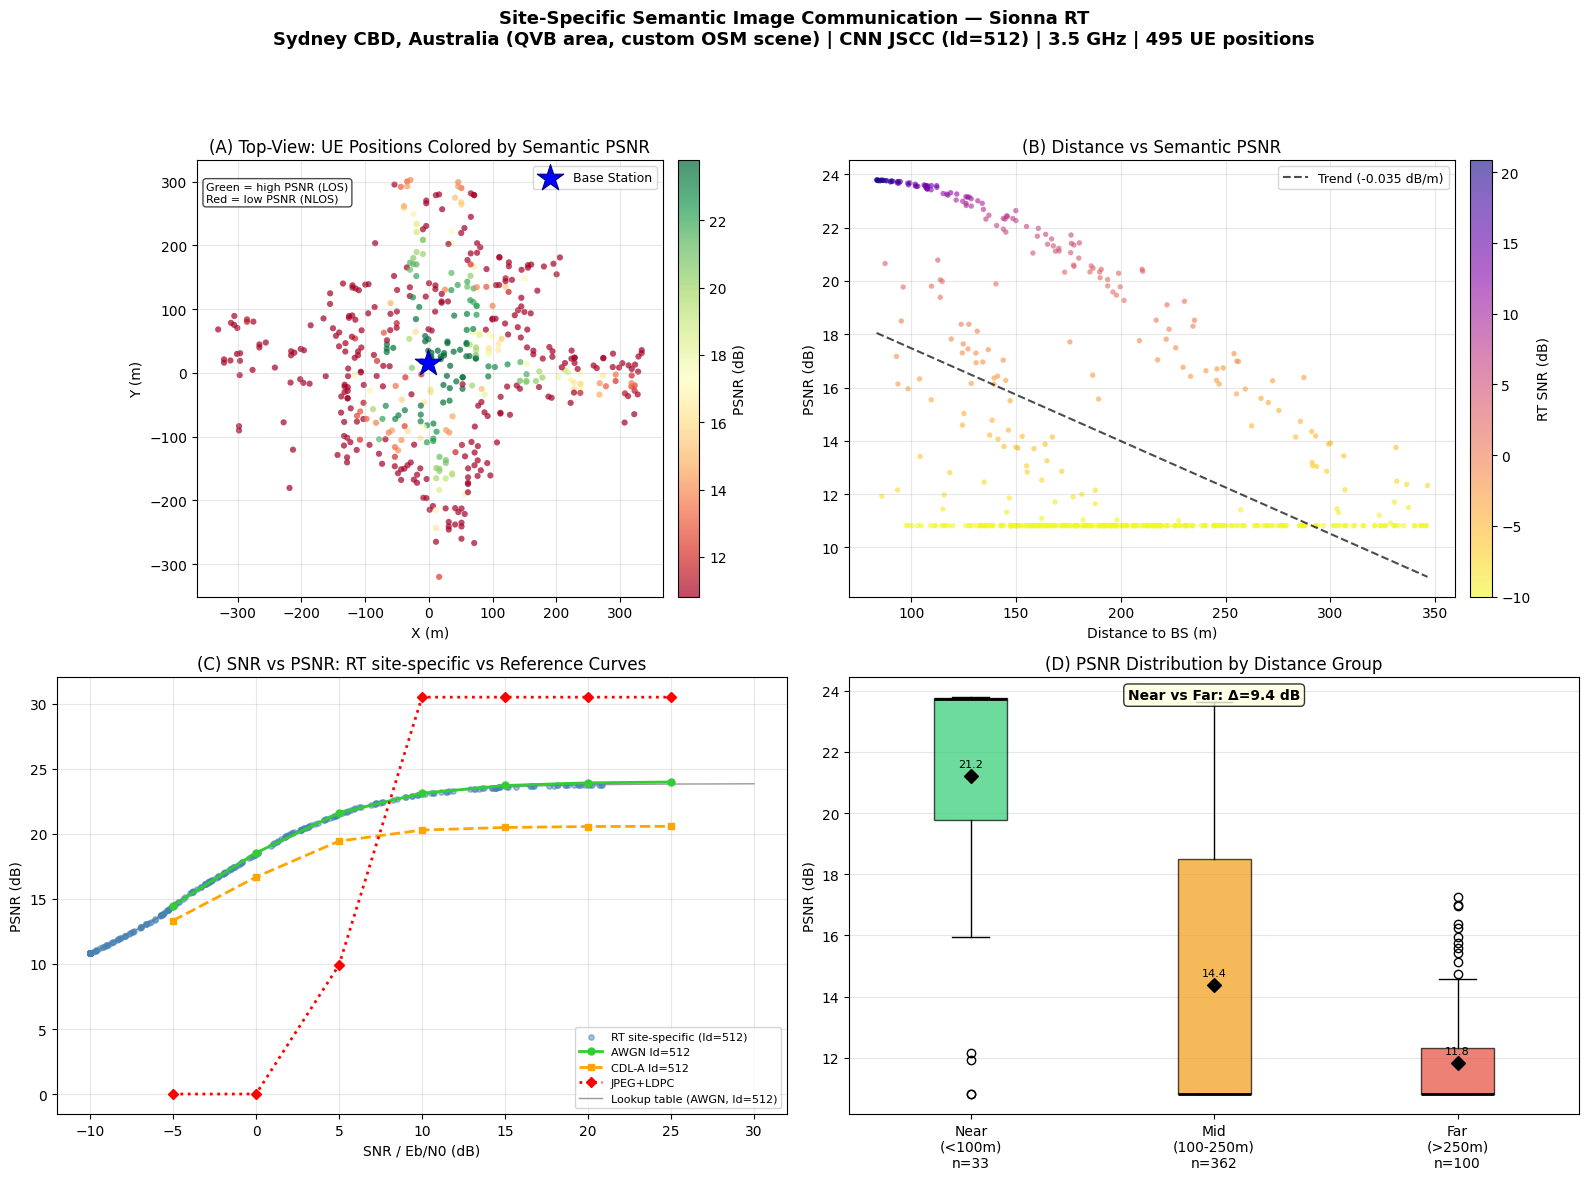

In [ ]:
from scipy.interpolate import griddata

# ── 四子图论文图 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f"Site-Specific Semantic Image Communication — Sionna RT\n"
    f"{SCENE_DESCRIPTION} | CNN JSCC (ld={LATENT_DIM}) | "
    f"3.5 GHz | {len(snr_arr)} UE positions",
    fontsize=13, fontweight='bold'
)

norm_psnr = mcolors.Normalize(vmin=psnr_arr.min(), vmax=psnr_arr.max())
norm_snr  = mcolors.Normalize(vmin=snr_arr.min(),  vmax=snr_arr.max())

# (A) 俯视图：UE 位置按 PSNR 着色
ax = axes[0, 0]
sc = ax.scatter(xs, ys, c=psnr_arr, cmap=cm.RdYlGn, norm=norm_psnr,
                s=20, alpha=0.7, edgecolors='none')
ax.scatter([BS_POS[0]], [BS_POS[1]], c='blue', marker='*', s=400, zorder=10,
           label='Base Station', edgecolors='navy', linewidths=0.8)
plt.colorbar(sc, ax=ax, label='PSNR (dB)', pad=0.02)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title('(A) Top-View: UE Positions Colored by Semantic PSNR')
ax.legend(fontsize=9); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.text(0.02, 0.95, 'Green = high PSNR (LOS)\nRed = low PSNR (NLOS)',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# (B) 距离 vs PSNR
ax = axes[0, 1]
sc2 = ax.scatter(distance_arr, psnr_arr, c=snr_arr, cmap=cm.plasma_r,
                 norm=norm_snr, s=15, alpha=0.6, edgecolors='none')
plt.colorbar(sc2, ax=ax, label='RT SNR (dB)', pad=0.02)
coeffs = np.polyfit(distance_arr, psnr_arr, 1)
x_fit  = np.linspace(distance_arr.min(), distance_arr.max(), 200)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'k--', lw=1.5, alpha=0.7,
        label=f'Trend ({coeffs[0]:.3f} dB/m)')
ax.set_xlabel('Distance to BS (m)'); ax.set_ylabel('PSNR (dB)')
ax.set_title('(B) Distance vs Semantic PSNR')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (C) SNR vs PSNR 对比曲线
ax = axes[1, 0]
ax.scatter(snr_arr, psnr_arr, c='steelblue', s=15, alpha=0.5,
           label=f'RT site-specific (ld={LATENT_DIM})', zorder=3)
for fpath, label, color, ls, marker in [
    ("checkpoints/image-jscc/eval/snr_recon_ld512.json",
     "AWGN ld=512",  "limegreen", "-",  "o"),
    ("checkpoints/image-jscc/eval/snr_recon_cdl_ld512.json",
     "CDL-A ld=512", "orange",    "--", "s"),
    ("checkpoints/image-jscc/eval/jpeg_baseline.json",
     "JPEG+LDPC",    "red",       ":",  "D"),
]:
    if os.path.exists(fpath):
        with open(fpath) as f:
            ref = json.load(f)
        ax.plot([r['ebno_db'] for r in ref], [r['psnr'] for r in ref],
                color=color, linestyle=ls, lw=2, marker=marker,
                markersize=5, label=label, zorder=5)
ax.plot(LOOKUP_SNRS, LOOKUP_PSNRS, 'k-', lw=1, alpha=0.4,
        label='Lookup table (AWGN, ld=512)', zorder=2)
ax.set_xlabel('SNR / Eb/N0 (dB)'); ax.set_ylabel('PSNR (dB)')
ax.set_title('(C) SNR vs PSNR: RT site-specific vs Reference Curves')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)
ax.set_xlim([-12, 32])

# (D) 箱线图
ax = axes[1, 1]
near = psnr_arr[distance_arr < 100]
mid  = psnr_arr[(distance_arr >= 100) & (distance_arr < 250)]
far  = psnr_arr[distance_arr >= 250]
bp   = ax.boxplot(
    [near, mid, far],
    labels=[f'Near\n(<100m)\nn={len(near)}',
            f'Mid\n(100-250m)\nn={len(mid)}',
            f'Far\n(>250m)\nn={len(far)}'],
    patch_artist=True, medianprops=dict(color='black', lw=2)
)
for patch, color in zip(bp['boxes'], ['#2ecc71', '#f39c12', '#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for i, g in enumerate([near, mid, far], 1):
    if len(g) > 0:
        ax.scatter(i, g.mean(), color='black', marker='D', s=50, zorder=5)
        ax.text(i, g.mean() + 0.3, f'{g.mean():.1f}', ha='center', fontsize=8)
if len(near) > 0 and len(far) > 0:
    ax.text(0.5, 0.95,
            f'Near vs Far: \u0394={near.mean()-far.mean():.1f} dB',
            transform=ax.transAxes, ha='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_ylabel('PSNR (dB)')
ax.set_title('(D) PSNR Distribution by Distance Group')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("site_specific_results.png", dpi=150, bbox_inches='tight')
plt.show()

#PSNR 热力图

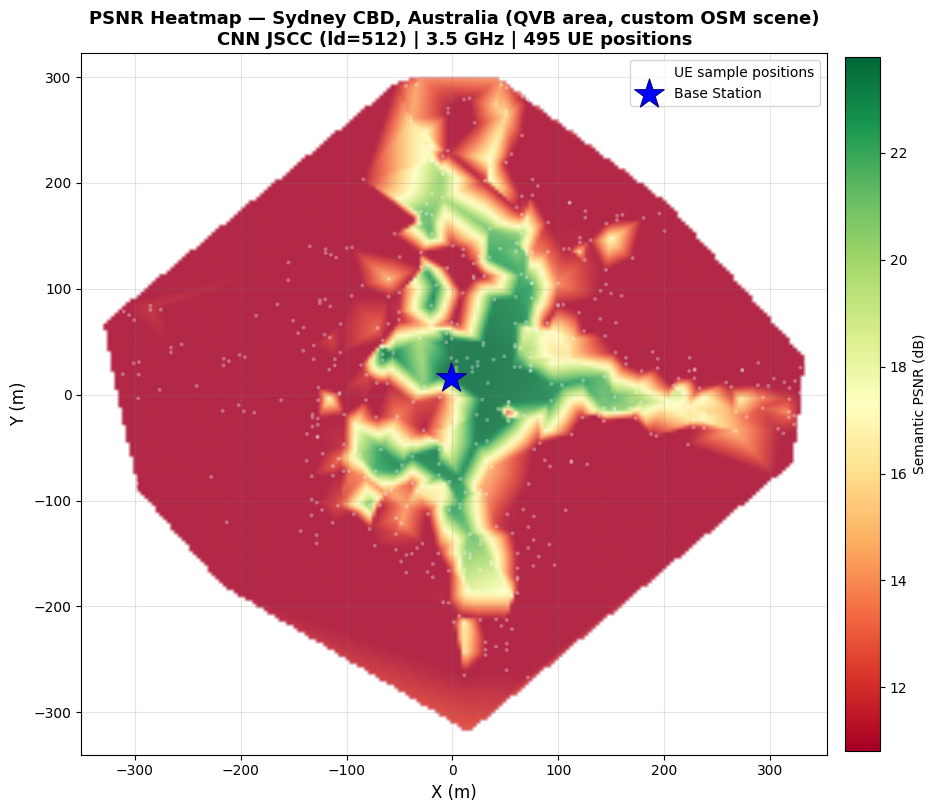

图表已保存: site_specific_results.png + site_specific_heatmap.png


In [ ]:
grid_resolution = 200
x_min, x_max = xs.min() - 20, xs.max() + 20
y_min, y_max = ys.min() - 20, ys.max() + 20
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, grid_resolution),
    np.linspace(y_min, y_max, grid_resolution)
)
grid_psnr = griddata(
    points=np.column_stack([xs, ys]),
    values=psnr_arr, xi=(grid_x, grid_y), method='linear'
)

# 用 RGBA 手动控制透明度，NaN 区域（凸包外）设为完全透明
norm_h   = mcolors.Normalize(vmin=psnr_arr.min(), vmax=psnr_arr.max())
rgba_img = cm.RdYlGn(norm_h(np.nan_to_num(grid_psnr, nan=0.0)))
rgba_img[..., 3] = np.where(np.isnan(grid_psnr), 0.0, 0.85)

fig2, ax2 = plt.subplots(figsize=(10, 9))
ax2.imshow(rgba_img, extent=[x_min, x_max, y_min, y_max],
           origin='lower', aspect='equal', interpolation='bilinear')
sm = cm.ScalarMappable(cmap=cm.RdYlGn, norm=norm_h)
sm.set_array([])
plt.colorbar(sm, ax=ax2, label='Semantic PSNR (dB)', pad=0.02, shrink=0.8)
ax2.scatter(xs, ys, c='white', s=8, alpha=0.3, edgecolors='none',
            label='UE sample positions')
ax2.scatter([BS_POS[0]], [BS_POS[1]], c='blue', marker='*', s=500, zorder=10,
            label='Base Station', edgecolors='navy', linewidths=0.8)
ax2.set_xlabel('X (m)', fontsize=12); ax2.set_ylabel('Y (m)', fontsize=12)
ax2.set_title(
    f'PSNR Heatmap — {SCENE_DESCRIPTION}\n'
    f'CNN JSCC (ld={LATENT_DIM}) | 3.5 GHz | {len(snr_arr)} UE positions',
    fontsize=13, fontweight='bold'
)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(True, alpha=0.2, color='gray')
plt.tight_layout()
plt.savefig("site_specific_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("图表已保存: site_specific_results.png + site_specific_heatmap.png")

# Cell 10 — 结果汇总
# 依赖：Cell 8 的所有数组，Cell 3 和 Cell 5 的配置变量

In [ ]:
near_mask = distance_arr < 100
mid_mask  = (distance_arr >= 100) & (distance_arr < 250)
far_mask  = distance_arr >= 250

print(f"""
{'='*60}
SITE-SPECIFIC EVALUATION SUMMARY
{'='*60}
场景：    {SCENE_DESCRIPTION}
频率：    3.5 GHz
基站：    {cfg['bs_position']}，{num_rx_ant} 天线
UE：      {num_tx_ant} 天线，{SAMPLE_MIN_DIST}-{SAMPLE_MAX_DIST} m 范围内随机采样
有效位置：{len(snr_arr)} 个

SNR：   {snr_arr.min():.1f} ~ {snr_arr.max():.1f} dB（均值 {snr_arr.mean():.1f} dB）
PSNR：  {psnr_arr.min():.2f} ~ {psnr_arr.max():.2f} dB（均值 {psnr_arr.mean():.2f} dB）

近距离 (<100m)，   n={near_mask.sum():3d}：PSNR = {psnr_arr[near_mask].mean():.2f} dB
中距离 (100-250m)，n={mid_mask.sum():3d}：PSNR = {psnr_arr[mid_mask].mean():.2f} dB
远距离 (>250m)，   n={far_mask.sum():3d}：PSNR = {psnr_arr[far_mask].mean():.2f} dB

★ 近距 vs 远距 PSNR 差 = \
{psnr_arr[near_mask].mean() - psnr_arr[far_mask].mean():.2f} dB
{'='*60}
""")



SITE-SPECIFIC EVALUATION SUMMARY
场景：    Sydney CBD, Australia (QVB area, custom OSM scene)
频率：    3.5 GHz
基站：    [-1.0, 15.7, 84.8]，16 天线
UE：      4 天线，10-350 m 范围内随机采样
有效位置：495 个
 
SNR：   -10.0 ~ 20.8 dB（均值 -4.3 dB）
PSNR：  10.82 ~ 23.79 dB（均值 14.32 dB）
 
近距离 (<100m)，   n= 33：PSNR = 21.21 dB
中距离 (100-250m)，n=362：PSNR = 14.38 dB
远距离 (>250m)，   n=100：PSNR = 11.84 dB
 
★ 近距 vs 远距 PSNR 差 = 9.37 dB



In [ ]:
# Cell 11 — 将结果保存到 Drive（便于本地下载）
import shutil
for fname in ["site_specific_results.json", "site_specific_results.png", "site_specific_heatmap.png"]:
    src = os.path.join(WORK_DIR, fname)
    if not os.path.exists(src):
        print(f"跳过（不存在）: {fname}")
        continue
    dst = f"{DRIVE_DIR}/{ACTIVE_SCENE}_{fname}"
    shutil.copy(src, dst)
    print(f"已保存到 Drive: {dst}")
